In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn  as sns

df = pd.read_csv('/kaggle/input/datasets/aliiihussain/amazon-sales-dataset/amazon_sales_dataset.csv')
df.describe()
df.head()


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [2]:
#no null rows 

df[df.isna().any(axis = 1)]

df['order_date'] = df['order_date'].astype('datetime64[ns]')
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day_name()
df['discount_amount'] = df['price'] - df['discounted_price']
avg_order_value = df['total_revenue'].sum() / df['order_id'].nunique()

df.head()

tick_dict = {'labelfontfamily' : 'DejaVu Sans' , 'labelcolor' : 'black' , 'labelsize' : 10}
title_dict = {'family' : 'DejaVu Sans' , 'color' : 'black' , 'fontweight' : 'bold' , 'fontsize' : 18}
label_dict = {'family' : 'DejaVu Sans' , 'color' : 'black' , 'weight' : 'bold' , 'size' : 18 , 'fontstyle' : 'italic'}


(0.0, 10000000.0)

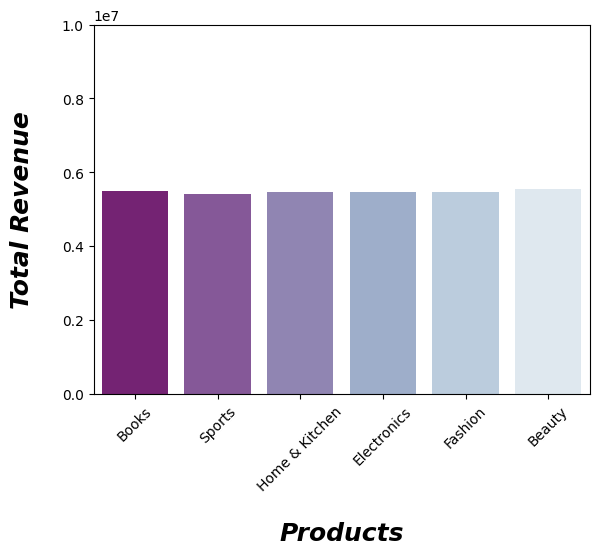

In [3]:
# product wise total revenue
prod = df.groupby([ 'product_category'] ).agg({'quantity_sold' : 'sum' ,'rating' : 'mean' , 'total_revenue' : 'sum'}).sort_values(by = ['rating' , 'total_revenue'] , ascending = [False , False] )

# df.head()
ax = sns.barplot( data = prod , x = 'product_category'  , y = 'total_revenue' , hue= 'product_category' , legend = False , palette='BuPu_r')
ax.tick_params(axis = 'y' , **tick_dict)
ax.tick_params(axis = 'x', rotation = 45 , **tick_dict)
ax.set_xlabel('Products' , labelpad= 20 , **label_dict)
ax.set_ylabel('Total Revenue' , labelpad= 20 , **label_dict)
ax.set_ylim(0 , 1e7)
# prod

[]

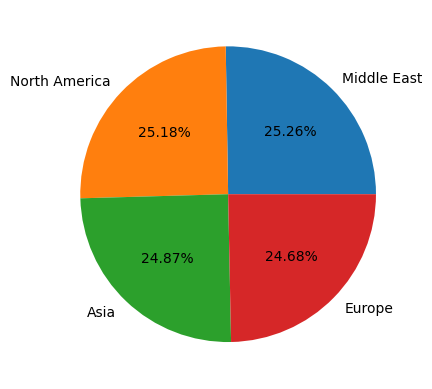

In [4]:
cust_reign = df.groupby([ 'customer_region'] ).agg({'quantity_sold' : 'sum' ,'rating' : 'mean' , 'total_revenue' : 'sum'}).sort_values(by = ['rating' , 'total_revenue'] , ascending = [False , False] )
plt.pie(x = cust_reign['total_revenue'] , labels = cust_reign.index , autopct = '%1.2f%%' )
plt.plot()

[]

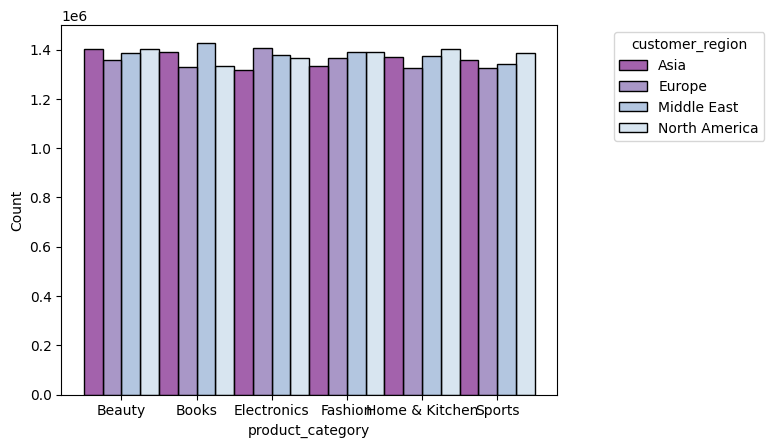

In [5]:
# How avg discount on products affect revenue generated  
# df[df['product_category'] == 'Books']

hist = df.groupby(['customer_region' , 'product_category' , ]).agg({'discount_amount' : 'mean' , 'total_revenue' : 'sum'})
histaxs = sns.histplot(data = hist , x = 'product_category' , hue = 'customer_region' , weights = 'total_revenue', palette = 'BuPu_r' , multiple = 'dodge' , element = 'bars' , log_scale = True )
sns.move_legend(histaxs , 'upper left' , bbox_to_anchor = (1.1, 1))
plt.plot()
#not much difference 

<Axes: xlabel='discount_percent', ylabel='total_revenue'>

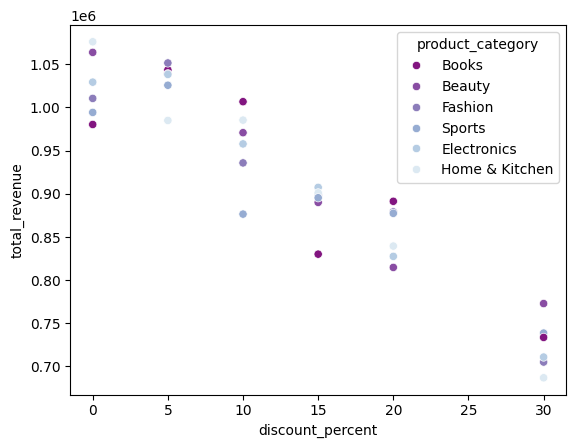

In [6]:
#product popularity countrywise

popularity = df.groupby(['product_category' , 'discount_percent'] ).agg({'quantity_sold' : 'sum' , 'total_revenue' : 'sum'}).sort_values(by = [ 'quantity_sold'] , ascending = [False])
# top2 = popularity.groupby(level = 'customer_region')['rating'].nlargest(2)
# top2.head(20)
sns.scatterplot(data = popularity , x = 'discount_percent' , y = 'total_revenue' , palette = 'BuPu_r' , hue = 'product_category')
# popularity

In [7]:
#csutomer Analysis
df.groupby('order_id').agg({'total_revenue' : 'sum'}).sort_values(by = 'total_revenue',ascending = False)


,total_revenue
order_id,
27833,2499.55
10794,2498.85
12128,2493.80
23880,2493.05
32944,2492.50
...,...
39466,4.79
28692,4.30
4199,4.29


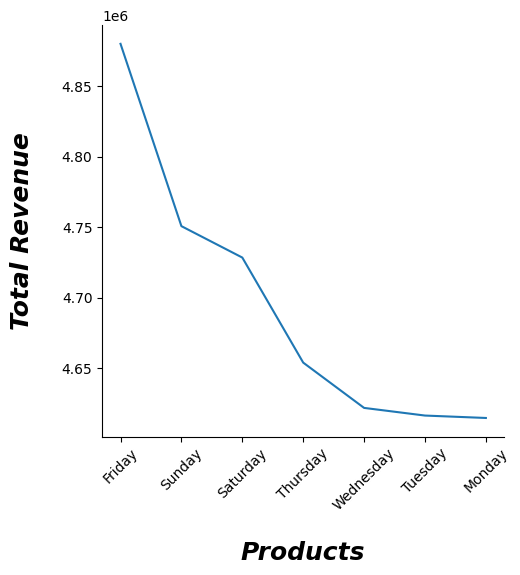

In [8]:
day = df.groupby(['day']).agg({'total_revenue' : 'sum'}).sort_values(by = ['total_revenue'] , ascending = [False])
year = df.groupby(['year']).agg({'total_revenue' : 'sum'}).sort_values(by = ['total_revenue'] , ascending = [False])
year_months = df.groupby(['year' , 'month']).agg({'total_revenue' : 'sum'}).sort_values(by = ['year' , 'total_revenue'] , ascending = [True , False ])

# sns.relplot(data = year , x = 'year' , y = 'total_revenue' , kind = 'line' , markers = True ) # only 2 years data available
day_sales = sns.relplot(data = day , x = 'day' , y = 'total_revenue' , kind = 'line' , markers = True )
day_sales.tick_params(axis = 'y' , **tick_dict)
day_sales.tick_params(axis = 'x', rotation = 45 , **tick_dict)
day_sales.set_axis_labels('Products' , 'Total Revenue' , labelpad= 20 , **label_dict)


<Axes: >

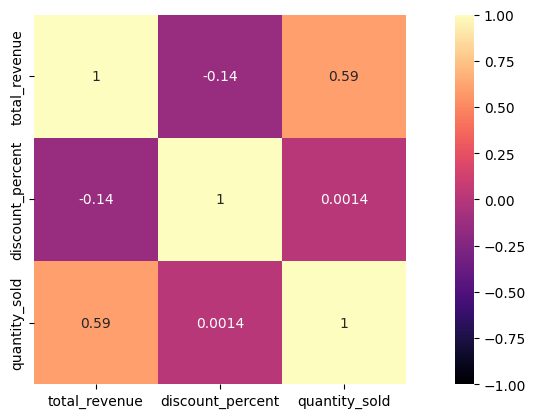

In [9]:
sns.heatmap(df[['total_revenue' , 'discount_percent' , 'quantity_sold']].corr() , annot = True , vmin = -1 , vmax = 1 , cmap = 'magma' , cbar_kws = { 'pad' : 0.1 })

# Modelling


In [10]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day,discount_amount
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,Wednesday,12.87
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,Sunday,60.52
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,Wednesday,99.16
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,Sunday,55.79
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,Sunday,0.00


In [11]:
# df_dummy = pd.get_dummies(df , drop_first = True)
# df_dummy.info()

Y = df['total_revenue']
X = df[['product_category' , 'price' , 'discount_percent' , 'quantity_sold' , 'customer_region' , 'rating']]

X = pd.get_dummies(X , ['product_category' , 'customer_region'] , drop_first = True)

In [12]:
from sklearn.model_selection import train_test_split

X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42)

In [13]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()

model.fit(X_train , Y_train)

Y_pred = model.predict(X_test)

# Evaluate Model

In [14]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

mse = mean_squared_error(Y_test , Y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test , Y_pred)
r2score = r2_score(Y_test , Y_pred)


mse
rmse
# mae
# r2score

np.float64(187.2175877928774)

## Visualize Model 

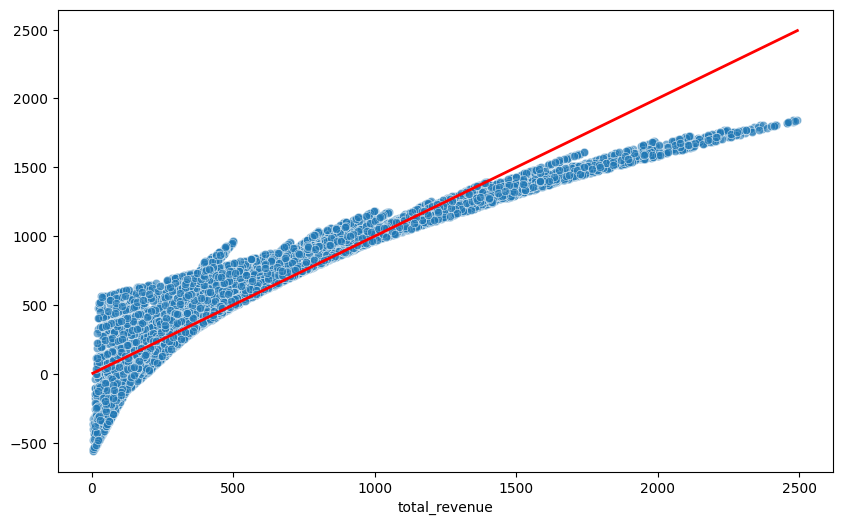

In [15]:
fig , axs = plt.subplots(1,1 , figsize = (10 , 6))

sns.scatterplot(ax = axs , x = Y_test , y = Y_pred , alpha = 0.6)
sns.lineplot( ax = axs , x = [Y_test.min() , Y_test.max()] , y = [Y_test.min() , Y_test.max()] , color = 'red' , lw = 2 )
plt.show()


### Residual plot

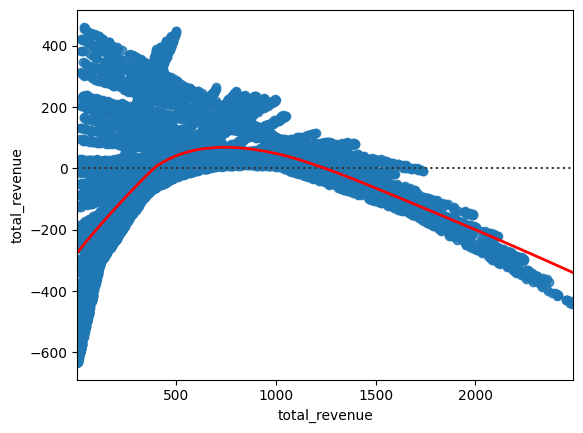

In [16]:
sns.residplot(x = Y_test , y = Y_pred - Y_test , lowess = True , line_kws = {'color' : 'red' , 'lw' : 2})
plt.show()